In [2]:
# Dependency imports

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Load the Stokes boundary layer data

In [3]:
# Data loading function

def load_data():
    my_train_path = "kaggle_train_Stokes.csv"
    my_benchmark_path = "kaggle_benchmark_Stokes.csv"
    return {"train": pd.read_csv(my_train_path), "secret_test": pd.read_csv(my_benchmark_path)}

In [4]:
# Load train and test dataframes from file.

data = load_data()
data["train"].head()


,id,h,omega,nu,U,u*,z*
0,0,714.848180,3.270814e-07,0.010348,3.936251,4.373923,714.848180
1,1,37.759470,5.967479e-04,0.028270,51.694711,55.009575,22.985011
2,2,4793.296822,5.002740e-11,0.000055,228.857112,246.913461,3986.903017
3,3,252.695524,2.312996e-05,0.016444,54.805944,58.478971,88.865519
4,4,5.221472,1.675826e-03,0.002551,33.446634,36.757917,5.221472


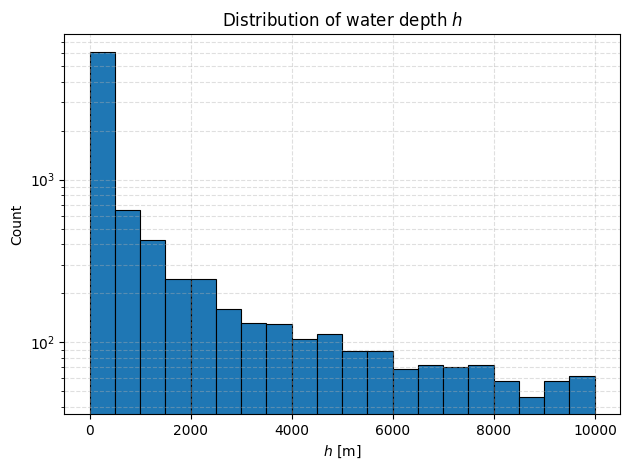

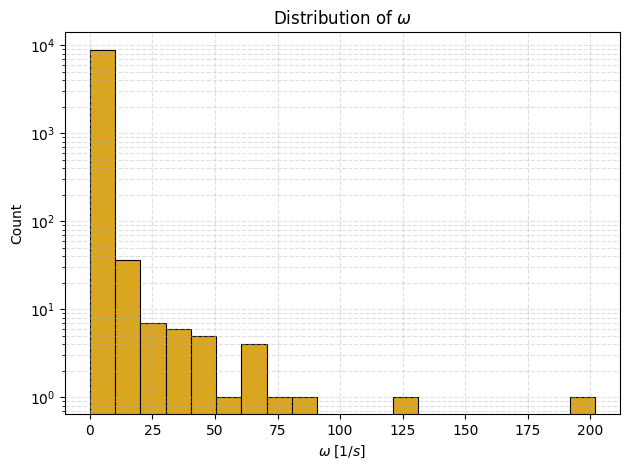

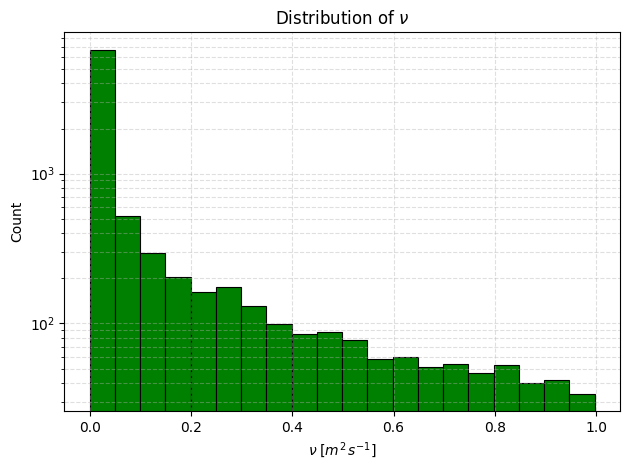

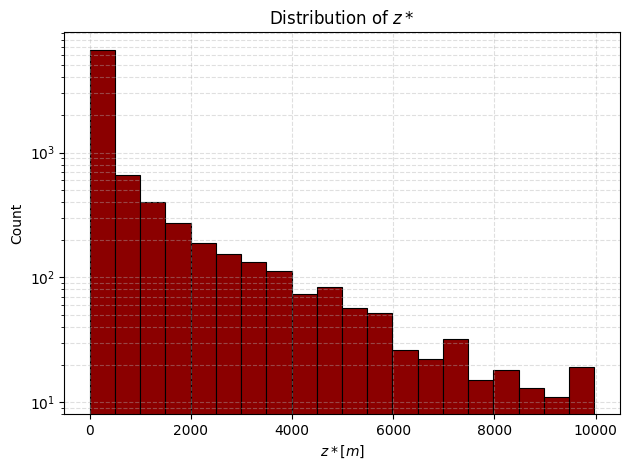

In [6]:
## Histogram of h
plt.hist(data["train"]["h"], bins=20, edgecolor="black", linewidth=0.8)
plt.yscale("log")
plt.title("Distribution of water depth $h$")
plt.xlabel(r"$h$ [m]")
plt.ylabel("Count")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## Histogram of omega
plt.hist(data["train"]["omega"], bins=20, edgecolor="black", linewidth=0.8, color="goldenrod")
plt.yscale("log")
plt.title("Distribution of $\\omega$")
plt.xlabel(r"$\omega\;[1/s]$")
plt.ylabel("Count")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## Histogram of nu
plt.hist(data["train"]["nu"], bins=20, edgecolor="black", linewidth=0.8, color="green")
plt.yscale("log")
plt.title("Distribution of $\\nu$")
plt.xlabel(r"$\nu\;[m^2\,s^{-1}]$")
plt.ylabel("Count")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## Histogram of z*
plt.hist(data["train"]["z*"], bins=20, edgecolor="black", linewidth=0.8, color="darkred")
plt.yscale("log")
plt.title("Distribution of $z*$")
plt.xlabel(r"$z* [m]$")
plt.ylabel("Count")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

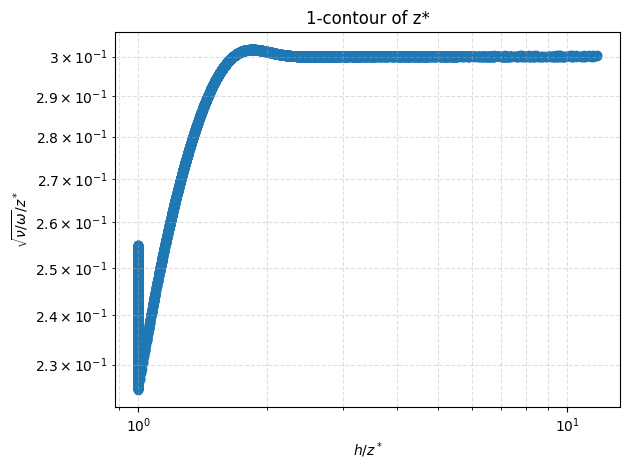

In [7]:
## System physics and plots for pt.I A

# Dimensionally homogeneous data
data_homog = pd.DataFrame()
data_homog["x0"] = data["train"]["h"]
data_homog["x1"] = np.sqrt(data["train"]["nu"] / data["train"]["omega"])
data_homog["z*"] = data["train"]["z*"]

# Dimensionless data
data_dimensionless = pd.DataFrame(columns=["x0", "y"])
data_dimensionless["x0"] = data_homog["x1"] / data_homog['x0']
data_dimensionless["y"] = data_homog["z*"] / data_homog['x0']

# Scaled homogeneous data for plotting 1-contour of z*
data_homog_scaled = data_homog.div(data_homog['z*'], axis=0)

# Plotting the 1-contour of z* in the homogeneous space
plt.scatter(data_homog_scaled["x0"], data_homog_scaled["x1"])
plt.xscale("log")
plt.yscale("log")
plt.title("1-contour of z*")
plt.xlabel(r"$h/z^*$")
plt.ylabel(r"$\sqrt{\nu/\omega}/z^*$")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.tight_layout()





## Linear Regression and Generalized Linear Regression

Best W: [np.float64(-0.024999999999999467), np.float64(3.700000000000001)]
Best MSRE: 0.69%


(np.float64(0.6903810570180542),
 0        640.245420
 1         24.522535
 2       3749.516875
 3         92.336287
 4          4.434846
            ...     
 8995     718.004116
 8996       1.423044
 8997    1043.701013
 8998    1376.134883
 8999       4.718036
 Length: 9000, dtype: float64)

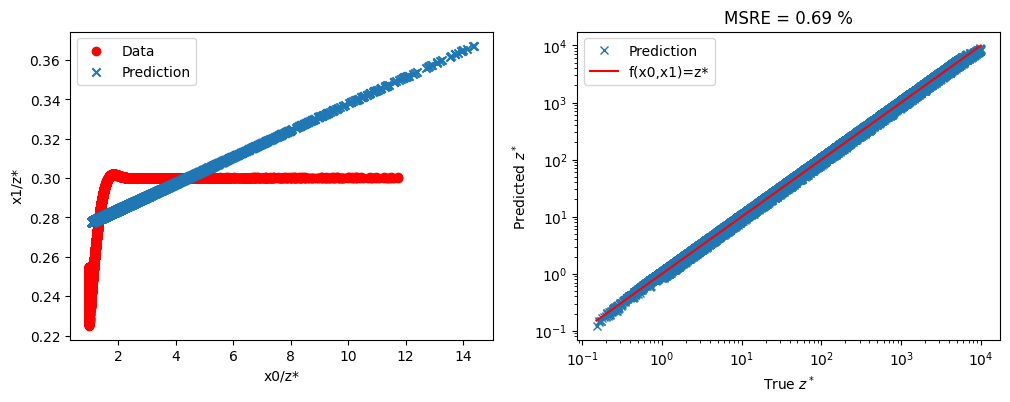

In [8]:
# Pt.I B: Linear regression and generalized linear regression

# Linear network model
def linear_network(x0, x1, W):
    """
    Linear fit of a response variable dependent 
    on explanatory variables x0, x1 weighted by W.
    """
    f = W[0]*x0 + W[1]*x1
    return x0/f, x1/f, f

# Loss functions

def msre(input, target):
    return 100 * np.square((target - input) / target).mean()

# Model evaluation and visualization function
def fit_and_validate(W, data, data_scaled, network):
    """
    input:
    W           array of weights
    data        input data
    data_scaled rescaled input data
    network     a function e.g. "linear_network" implemented above
    
    output: 
    accuracy     the error metric value
    z_pred       the predicted z* values
    """

    # Compute the prediction of the network
    x0, x1, z_pred = network(data['x0'], data['x1'], W)

    # Compute the msre
    accuracy = msre(z_pred, data['z*'])

    # Recreate the figure with the two plots shown above
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.scatter(data_scaled.x0, data_scaled.x1, color="red", label="Data")
    ax1.scatter(x0, x1, marker="x", label="Prediction")
    ax1.set_xlabel("x0/z*")
    ax1.set_ylabel("x1/z*")
    ax1.legend()
    
    # Visualize the prediction vs reference in a log-log plot
    ax2.loglog(data['z*'], z_pred, marker="x", ls='', label="Prediction")

    # Create the diagonal line
    z = [data['z*'].min(), data['z*'].max()]
    ax2.plot(z, z, color='r', label = "f(x0,x1)=z*")

    # Report the error in the plot title
    ax2.set_title(f"MSRE = {accuracy:.2f} %" )
    ax2.set_xlabel(r"True $z^*$")
    ax2.set_ylabel(r"Predicted $z^*$")
    ax2.legend()

    return accuracy, z_pred


# Grid search for the best weights W in the linear network model
w0_candidates = np.linspace(-5.0, 5.0, 401)
w1_candidates = np.linspace(-5.0, 5.0, 401)

x0 = data_homog["x0"]
x1 = data_homog["x1"]
z_true = data_homog["z*"]

best_W = None
best_msre = np.inf

for w0 in w0_candidates:
    for w1 in w1_candidates:
        _, _, z_pred = linear_network(x0, x1, [w0, w1])
        current_msre = msre(z_pred, z_true)

        if current_msre < best_msre:
            best_msre = current_msre
            best_W = [w0, w1]

print(f"Best W: {best_W}")
print(f"Best MSRE: {best_msre:.2f}%")

fit_and_validate(best_W, data_homog, data_homog_scaled, linear_network)



(np.float64(0.6903810570180546),
 0        640.245420
 1         24.522535
 2       3749.516875
 3         92.336287
 4          4.434846
            ...     
 8995     718.004116
 8996       1.423044
 8997    1043.701013
 8998    1376.134883
 8999       4.718036
 Length: 9000, dtype: float64)

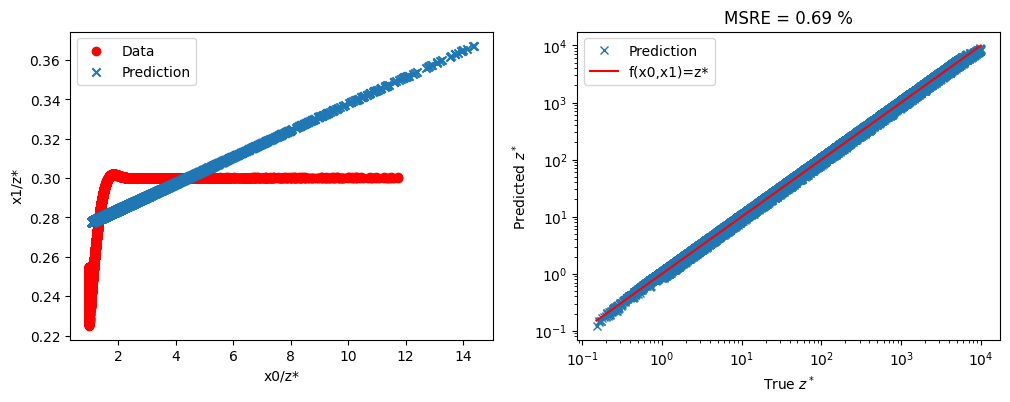

In [9]:
# Plots for the best W found in the grid search
fit_and_validate([-0.025, 3.7], data_homog, data_homog_scaled, linear_network)

Best W: [np.float64(0.125), np.float64(4.875), np.float64(-0.875)]
Best MSRE: 0.60%


(np.float64(0.5990551706657947),
 0        644.461286
 1         24.167762
 2       3738.251164
 3         89.746979
 4          4.446916
            ...     
 8995     715.510884
 8996       1.414394
 8997    1013.724870
 8998    1340.965635
 8999       4.629841
 Length: 9000, dtype: float64)

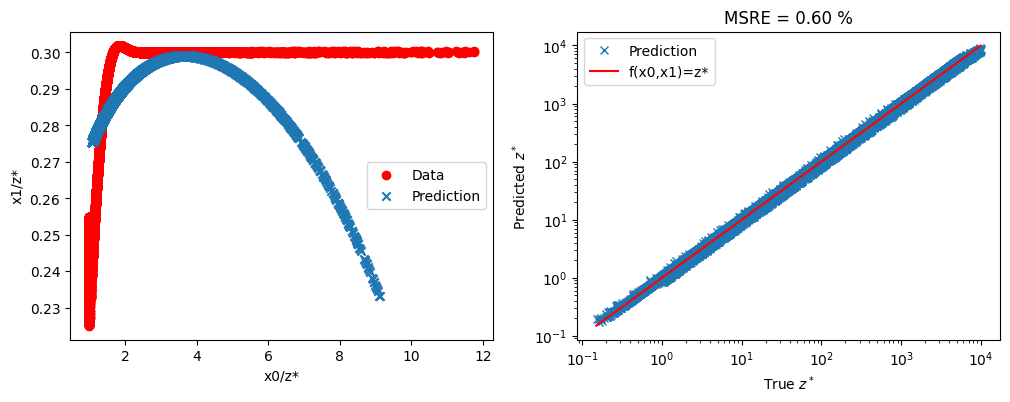

In [11]:
# Generalized linear network model
def generalized_linear_network(x0, x1, W):
    f = W[0]*x0 + W[1]*x1 + W[2] * np.sqrt(x0 * x1)
    
    return x0/f, x1/f, f

# Grid search for the best weights W in the generalized linear network model
w0_candidates = np.linspace(-5.0, 5.0, 81)
w1_candidates = np.linspace(-5.0, 5.0, 81)
w2_candidates = np.linspace(-5.0, 5.0, 81)

best_W = None
best_msre = np.inf

for w0 in w0_candidates:
    for w1 in w1_candidates:
        for w2 in w2_candidates:
            _, _, z_pred = generalized_linear_network(x0, x1, [w0, w1, w2])
            current_msre = msre(z_pred, z_true)

            if current_msre < best_msre:
                best_msre = current_msre
                best_W = [w0, w1, w2]

print(f"Best W: {best_W}")
print(f"Best MSRE: {best_msre:.2f}%")

fit_and_validate(best_W, data_homog, data_homog_scaled, generalized_linear_network)



0.5990551706657947


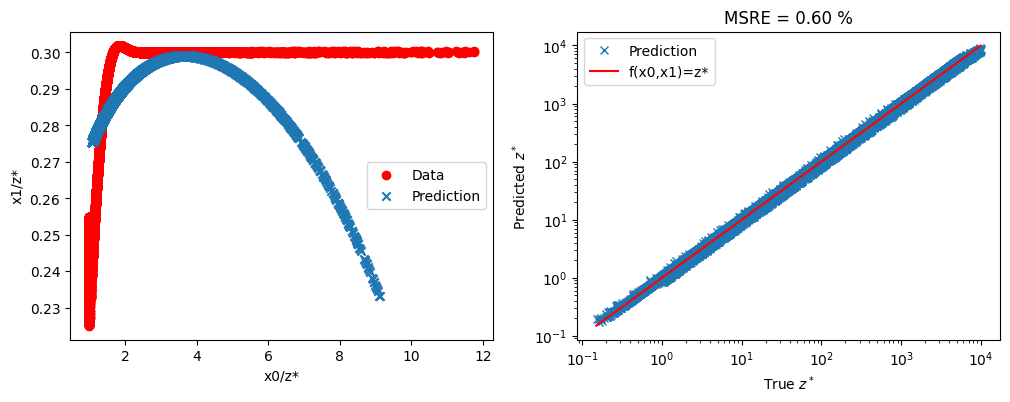

In [12]:
# Plots for the best W found in the grid search and error reporting
fit_and_validate([0.125, 4.875, -0.875], data_homog, data_homog_scaled, generalized_linear_network)
_, _, z_pred = generalized_linear_network(x0, x1, [0.125, 4.875, -0.875])
current_msre = msre(z_pred, z_true)
print(current_msre)



## Building blocks for neural networks - 2-N-N-1 model SGD

In [13]:
# Network weight initialization function
# Check the assignment text for a different way to initialize your weights.

def init_weights(input_dim, output_dim, sigma=0.2):
    return np.random.normal(0.0, sigma, (input_dim, output_dim))


In [14]:
# Activation functions

def relu(input):
    return np.maximum(0, input)

In [15]:
# Loss functions

def msre(input, target):
    return np.square((target - input) / target).mean()

In [16]:
# Predict using a trained set of model weights for 2 hidden layers

def predict(input, weights):

    [w1, w2, w3] = weights

    x1 = relu(input @ w1)
    x2 = relu(x1 @ w2)
    return x2 @ w3



In [17]:
# Function to train a simple 2-N-N-1 model.
# NOTE: This function expects numpy matrices for the train and test data.
#       If your train and test data is stored in pandas dataframes you 
#       can convert using the `.to_numpy()` function.


def train_model(
    num_neurons, epochs, train, test, lr
): 
    
    w1 = init_weights(2, num_neurons, sigma=0.2)
    w2 = init_weights(num_neurons, num_neurons, sigma=0.2)
    w3 = init_weights(num_neurons, 1, sigma=0.2)

    train_loss = []
    test_loss = []

    for epoch in range(epochs):
        epoch_loss = 0.0

        # Randomly shuffle the training data at the start of each epoch
        perm = np.random.permutation(train.shape[0])

        # Iterate through the training data in the shuffled order
        for idx in perm:

            # Reshape the current training example to be a 2D array with shape (1, 3)
            entry = np.asarray(train[idx]).reshape(1, -1)

            # Split the input and output (label)
            x0 = entry[:, :2]
            y = entry[:, 2:3]

            # Forward pass (z1 and z2 - hidden layers, z3 - final output)
            z1 = x0 @ w1
            x1 = relu(z1)
            z2 = x1 @ w2
            x2 = relu(z2)
            z3 = x2 @ w3

            # Compute error
            loss = msre(z3, y)
            epoch_loss += loss

            ## Backward pass

            # Compute gradient of the loss with respect to the output (z3)
            dE_dz3 = 2.0 * (z3 - y) / (np.square(y))

            # Gradient for the output weights
            dE_dw3 = x2.T @ dE_dz3

            # Gradient for the 2nd hidden layer x2
            dE_dx2 = dE_dz3 @ w3.T
            relu_grad_2 = np.where(z2 > 0, 1.0, 0.0)
            dE_dz2 = dE_dx2 * relu_grad_2

            # Gradient for the 2nd layer weights
            dE_dw2 = x1.T @ dE_dz2

            # Gradient for the 1st hidden layer x1
            dE_dx1 = dE_dz2 @ w2.T
            relu_grad_1 = np.where(z1 > 0, 1.0, 0.0)
            dE_dz1 = dE_dx1 * relu_grad_1

            # Gradients for 1st layer weights
            dE_dw1 = x0.T @ dE_dz1

            # SGD updates for the weights
            w3 -= lr * dE_dw3
            w2 -= lr * dE_dw2
            w1 -= lr * dE_dw1

        # Mean training loss for this epoch
        loss_this_epoch = epoch_loss / train.shape[0]
        train_loss.append(loss_this_epoch)

        # Compute and store test loss
        pred = predict(test[:, :2], [w1, w2, w3])
        test_loss.append(msre(pred, test[:, 2:3]))

    return [[train_loss, test_loss], [w1, w2, w3]]



In [18]:
# Train/test split for the neural network model

# Convert the homogeneous data to a numpy array for training
all_samples = data_homog[["x0", "x1", "z*"]].to_numpy()

# 80:20 train/test split
num_samples = all_samples.shape[0]
num_train = int(0.8 * num_samples)

# Randomly shuffle the data and split into train and test sets
perm = np.random.permutation(num_samples)

train_np = all_samples[perm[:num_train]]
test_np = all_samples[perm[num_train:]]

print(f"Train shape: {train_np.shape}")
print(f"Test shape: {test_np.shape}")



Train shape: (7200, 3)
Test shape: (1800, 3)


In [19]:
# Train M-neuron model example
(loss_curves, weights) = train_model(
    num_neurons=24,
    epochs=100,
    train=train_np,
    test=test_np,
    lr=5e-4
)

train_loss, test_loss = loss_curves

print(f"Final train MSRE: {train_loss[-1]:.6f}")
print(f"Final test  MSRE: {test_loss[-1]:.6f}")


Final train MSRE: 0.000932
Final test  MSRE: 0.000818


np.float64(0.0009226130653664809)

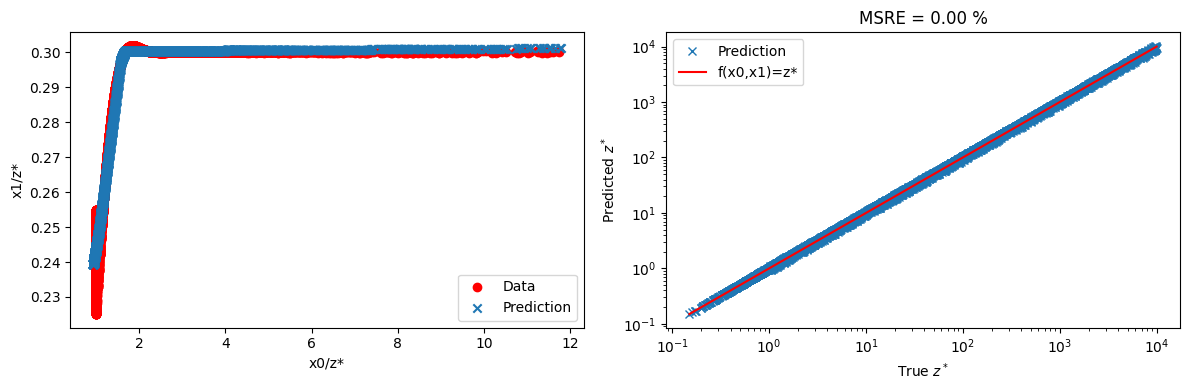

In [20]:
# Function to visualize the learned model behavior.

def plot_behavior(data, pred):
    """
    data: numpy array with columns [x0, x1, z*] and shape (N, 3)
    pred: predicted z* values with shape (N,) or (N, 1)
    """
    arr = np.asarray(data)
    x0_raw = arr[:, 0]
    x1_raw = arr[:, 1]
    z_true = arr[:, 2]

    # Ensure pred is a 1D array
    z_pred = np.asarray(pred).reshape(-1)

    # Scale the data and predictions by z* to visualize the 1-contour plot
    data_x0_scaled = x0_raw / z_true
    data_x1_scaled = x1_raw / z_true
    pred_x0_scaled = x0_raw / z_pred
    pred_x1_scaled = x1_raw / z_pred

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Left panel: scaled contour points
    ax1.scatter(data_x0_scaled, data_x1_scaled, color="red", label="Data")
    ax1.scatter(pred_x0_scaled, pred_x1_scaled, marker="x", label="Prediction")
    ax1.set_xlabel("x0/z*")
    ax1.set_ylabel("x1/z*")
    ax1.legend()

    # Right panel: prediction vs reference
    ax2.loglog(z_true, z_pred, marker="x", ls='', label="Prediction")
    z = [z_true.min(), z_true.max()]
    ax2.plot(z, z, color='r', label="f(x0,x1)=z*")

    err = msre(z_pred, z_true)
    ax2.set_title(f"MSRE = {err:.2f} %")
    ax2.set_xlabel(r"True $z^*$")
    ax2.set_ylabel(r"Predicted $z^*$")
    ax2.legend()

    plt.tight_layout()
    # Return the error value for potential further use
    return err

# Example of using the plot_behavior function
pred_train = predict(train_np[:, :2], weights)
plot_behavior(train_np, pred_train)



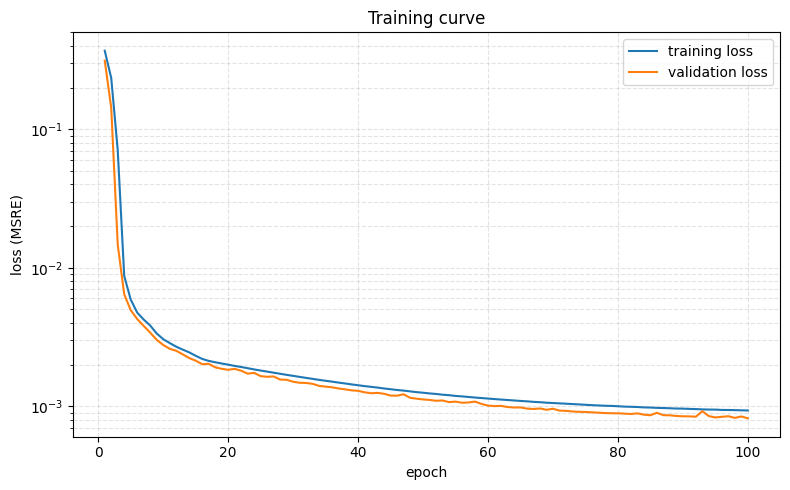

In [21]:
# Plot training and validation loss across epochs.

def plot_epoch(train_loss, test_loss=None):
    # Ensure train_loss is a 1D array
    train_loss = np.asarray(train_loss).reshape(-1)
    epochs = np.arange(1, len(train_loss) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, train_loss, label='training loss')

    # Ensure test_loss is a 1D array
    test_loss = np.asarray(test_loss).reshape(-1)
    plt.plot(epochs, test_loss, label='validation loss')

    plt.yscale('log')
    plt.xlabel('epoch')
    plt.ylabel('loss (MSRE)')
    plt.title('Training curve')
    plt.grid(True, which='both', linestyle='--', alpha=0.35)
    plt.legend()
    plt.tight_layout()

# Example of using the plot_epoch function
train_loss, test_loss = loss_curves
plot_epoch(train_loss, test_loss)




## Mini-batch SGD

In [28]:
# Function to train a simple 2-N-N-1 model using mini-batch SGD.
# NOTE: This function expects numpy matrices for the train and test data.
#       If your train and test data is stored in pandas dataframes you 
#       can convert using the `.to_numpy()` function.

def train_model_mb(
    num_neurons,
    epochs,
    train,
    test,
    batch_size,
    lr_start,
    lr_late,
    switch_epoch
):
    
    w1 = init_weights(2, num_neurons, sigma=0.2)
    w2 = init_weights(num_neurons, num_neurons, sigma=0.2)
    w3 = init_weights(num_neurons, 1, sigma=0.2)

    # Until at least one hidden neuron is active for some train samples in both hidden layers

    train_loss = []
    test_loss = []

    num_samples = train.shape[0]

    # Learning rate change implementation. 
    if lr_late is None:
        lr_late = lr_start
    if switch_epoch is None:
        switch_epoch = int(0.7 * epochs)

    # Main training loop with mini-batch SGD and learning rate scheduling
    for epoch in range(epochs):
        epoch_loss = 0.0

        # Use higher LR before switch, then lower LR after switch
        current_lr = lr_start if epoch < switch_epoch else lr_late

        # Randomly shuffle the training data at the start of each epoch
        perm = np.random.permutation(num_samples)

        # Iterate through the training data in mini-batches
        for start in range(0, num_samples, batch_size):
            batch_idx = perm[start:start + batch_size]
            batch = train[batch_idx]

            # Split the input and output (label)
            x0 = batch[:, :2]
            y = batch[:, 2:3]

            # Forward pass (z1 and z2 - hidden layers, z3 - final output)
            z1 = x0 @ w1
            x1 = relu(z1)
            z2 = x1 @ w2
            x2 = relu(z2)
            z3 = x2 @ w3

            # Compute error
            loss = msre(z3, y)
            epoch_loss += loss * batch.shape[0]

            ## Backward pass

            # Compute gradient of the loss with respect to the output (z3)
            # Divide by batch size so updates stay stable when batch_size changes
            b = batch.shape[0]
            dE_dz3 = 2.0 * (z3 - y) / (np.square(y)) / b

            # Gradient for the output weights
            dE_dw3 = x2.T @ dE_dz3

            # Gradient for the 2nd hidden layer x2
            dE_dx2 = dE_dz3 @ w3.T
            relu_grad_2 = np.where(z2 > 0, 1.0, 0.0)
            dE_dz2 = dE_dx2 * relu_grad_2

            # Gradient for the 2nd layer weights
            dE_dw2 = x1.T @ dE_dz2

            # Gradient for the 1st hidden layer x1
            dE_dx1 = dE_dz2 @ w2.T
            relu_grad_1 = np.where(z1 > 0, 1.0, 0.0)
            dE_dz1 = dE_dx1 * relu_grad_1

            # Gradients for 1st layer weights
            dE_dw1 = x0.T @ dE_dz1

            # SGD updates for the weights
            w3 -= current_lr * dE_dw3
            w2 -= current_lr * dE_dw2
            w1 -= current_lr * dE_dw1

        # Mean training loss for this epoch
        loss_this_epoch = epoch_loss / num_samples
        train_loss.append(loss_this_epoch)

        # Compute and store test loss
        pred = predict(test[:, :2], [w1, w2, w3])
        test_loss.append(msre(pred, test[:, 2:3]))

        #Checkpoint every 5000 epochs
        if (epoch + 1) % 2500 == 0:
            print(f"Epoch {epoch + 1}/{epochs} | train={train_loss[-1]:.9e} | test={test_loss[-1]:.9e}")


    return [[train_loss, test_loss], [w1, w2, w3]]

Epoch 2500/50000 | train=2.616533839e-05 | test=1.552713799e-05
Epoch 5000/50000 | train=1.644519578e-05 | test=9.646189642e-06
Epoch 7500/50000 | train=7.634112566e-06 | test=6.777651198e-06
Epoch 10000/50000 | train=6.610381388e-06 | test=3.633740936e-06
Epoch 12500/50000 | train=4.419711945e-06 | test=3.389312495e-06
Epoch 15000/50000 | train=3.952875719e-06 | test=2.691991854e-06
Epoch 17500/50000 | train=3.145568559e-06 | test=2.090937423e-06
Epoch 20000/50000 | train=3.538513513e-06 | test=2.532303179e-06
Epoch 22500/50000 | train=3.016003087e-06 | test=2.230800948e-06
Epoch 25000/50000 | train=2.663076892e-06 | test=2.491508101e-06
Epoch 27500/50000 | train=2.288669273e-06 | test=1.662458180e-06
Epoch 30000/50000 | train=1.982842795e-06 | test=1.447346025e-06
Epoch 32500/50000 | train=2.079005797e-06 | test=1.424539409e-06
Epoch 35000/50000 | train=2.209700759e-06 | test=1.240101015e-06
Epoch 37500/50000 | train=1.635851017e-06 | test=1.730449577e-06
Epoch 40000/50000 | train=2.

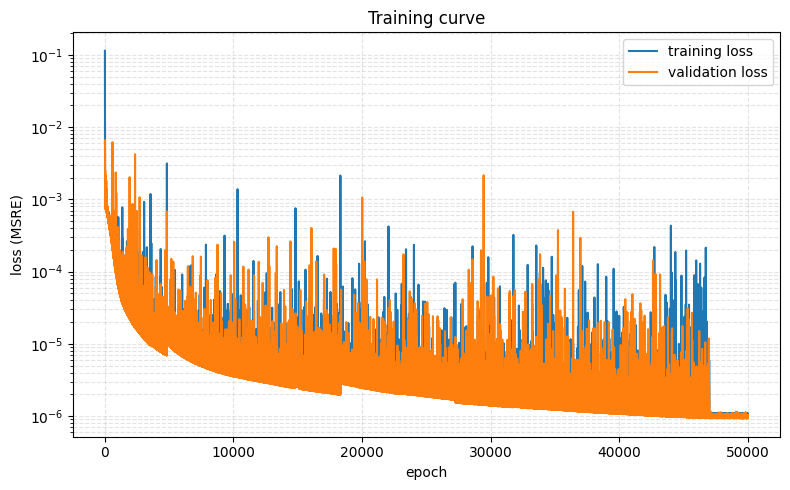

In [29]:
# Implementation of the mini-batch training function

(loss_curves_mb, weights_mb) = train_model_mb(
    num_neurons=100,
    epochs=50000,
    train=train_np,
    test=test_np,
    lr_start=100e-4,
    lr_late=10e-4,
    switch_epoch=47000,
    batch_size=8
)

train_loss_mb, test_loss_mb = loss_curves_mb
print(f"Final train MSRE: {train_loss_mb[-1]:.9f}")
print(f"Final test  MSRE: {test_loss_mb[-1]:.9f}")




plot_epoch(train_loss_mb, test_loss_mb)



In [30]:
# For submission to Kaggle

# Load benchmark data
bench = pd.read_csv("kaggle_benchmark_Stokes.csv")

# Build inputs exactly like training
x0_b = bench["h"].to_numpy()
x1_b = np.sqrt(bench["nu"].to_numpy() / bench["omega"].to_numpy())
X_bench = np.column_stack([x0_b, x1_b])

# Predict with weights
pred_bench = predict(X_bench, weights_mb).reshape(-1)

# Build Kaggle submission
submission = pd.DataFrame({
    "id": bench["id"].astype(int),
    "prediction": pred_bench
})

submission.to_csv("submission.csv", index=False)
submission.head()

,id,prediction
0,0,6.200640
1,1,140.766222
2,2,2.095644
3,3,1.044212
4,4,48.621171


## Dimensionless SGD implementation

In [31]:
# Function to train a 1-N-N-1 dimensionless model and return homogeneous-form outputs
# NOTE: This function expects numpy matrices for the train and test data.
#       If your train and test data is stored in pandas dataframes you 
#       can convert using the `.to_numpy()` function.


def train_model_dim(
    num_neurons, epochs, train, test, lr, train_h=None, test_h=None
):
    
    # Weights
    w1 = init_weights(1, num_neurons, sigma=0.2)
    w2 = init_weights(num_neurons, num_neurons, sigma=0.2)
    w3 = init_weights(num_neurons, 1, sigma=0.2)

    # Trainable biases
    b1 = np.zeros((1, num_neurons))
    b2 = np.zeros((1, num_neurons))
    b3 = np.zeros((1, 1))

    train_loss = []
    test_loss = []

    for epoch in range(epochs):
        epoch_loss = 0.0

        # Randomly shuffle the training data at the start of each epoch
        perm = np.random.permutation(train.shape[0])

        # Iterate through the training data in the shuffled order
        for idx in perm:

            # Reshape the current training example to be a 2D array with shape (1, 2)
            entry = np.asarray(train[idx]).reshape(1, -1)

            # Split the input and output (label)
            x0 = entry[:, :1]
            y = entry[:, 1:2]

            # Forward pass (z1 and z2 - hidden layers, z3 - final output)
            z1 = x0 @ w1 + b1
            x1 = relu(z1)
            z2 = x1 @ w2 + b2
            x2 = relu(z2)
            z3 = x2 @ w3 + b3

            # Compute error
            loss = msre(z3, y)
            epoch_loss += loss

            ## Backward pass

            # Compute gradient of the loss with respect to the output (z3)
            dE_dz3 = 2.0 * (z3 - y) / (np.square(y) + 1e-12)

            # Gradient for the output layer parameters
            dE_dw3 = x2.T @ dE_dz3
            dE_db3 = dE_dz3

            # Gradient for the 2nd hidden layer x2
            dE_dx2 = dE_dz3 @ w3.T
            relu_grad_2 = np.where(z2 > 0, 1.0, 0.0)
            dE_dz2 = dE_dx2 * relu_grad_2

            # Gradient for the 2nd layer parameters
            dE_dw2 = x1.T @ dE_dz2
            dE_db2 = dE_dz2

            # Gradient for the 1st hidden layer x1
            dE_dx1 = dE_dz2 @ w2.T
            relu_grad_1 = np.where(z1 > 0, 1.0, 0.0)
            dE_dz1 = dE_dx1 * relu_grad_1

            # Gradient for the 1st layer parameters
            dE_dw1 = x0.T @ dE_dz1
            dE_db1 = dE_dz1

            # SGD updates for weights and biases
            w3 -= lr * dE_dw3
            b3 -= lr * dE_db3
            w2 -= lr * dE_dw2
            b2 -= lr * dE_db2
            w1 -= lr * dE_dw1
            b1 -= lr * dE_db1

        # Mean training loss for this epoch
        loss_this_epoch = epoch_loss / train.shape[0]
        train_loss.append(loss_this_epoch)

        # Compute and store test loss
        x_test = test[:, :1]
        y_test = test[:, 1:2]
        pred = relu(relu(x_test @ w1 + b1) @ w2 + b2) @ w3 + b3
        test_loss.append(msre(pred, y_test))

    # Final dimensionless predictions
    x_train = train[:, :1]
    x_test = test[:, :1]
    y_pred_train_dim = relu(relu(x_train @ w1 + b1) @ w2 + b2) @ w3 + b3
    y_pred_test_dim = relu(relu(x_test @ w1 + b1) @ w2 + b2) @ w3 + b3

    # Package homogeneous-form outputs if aligned homogeneous arrays are provided
    dim_outputs = {
        "y_pred_train_dim": y_pred_train_dim.reshape(-1),
        "y_pred_test_dim": y_pred_test_dim.reshape(-1),
        "train_data_h": None,
        "test_data_h": None,
        "z_pred_train": None,
        "z_pred_test": None,
    }

    if train_h is not None and test_h is not None:
        train_h_arr = np.asarray(train_h)
        test_h_arr = np.asarray(test_h)

        # Recover physical z* from y_dim = z*/h  => z* = y_dim * h
        z_pred_train = y_pred_train_dim.reshape(-1) * train_h_arr[:, 0]
        z_pred_test = y_pred_test_dim.reshape(-1) * test_h_arr[:, 0]

        dim_outputs["train_data_h"] = train_h_arr
        dim_outputs["test_data_h"] = test_h_arr
        dim_outputs["z_pred_train"] = z_pred_train
        dim_outputs["z_pred_test"] = z_pred_test

    return [[train_loss, test_loss], [w1, b1, w2, b2, w3, b3], dim_outputs]



In [32]:
# Train/test split for the dimensionless neural network model

# Convert the dimensionless data to a numpy array for training
all_samples_dim = data_dimensionless[["x0", "y"]].to_numpy()

# Keep aligned homogeneous data for plotting with the original plot_behavior
all_samples_h = data_homog[["x0", "x1", "z*"]].to_numpy()

# 80:20 train/test split
num_samples_dim = all_samples_dim.shape[0]
num_train_dim = int(0.8 * num_samples_dim)

# Randomly shuffle the data and split into train and test sets
perm_dim = np.random.permutation(num_samples_dim)

train_dim = all_samples_dim[perm_dim[:num_train_dim]]
test_dim = all_samples_dim[perm_dim[num_train_dim:]]

# Aligned homogeneous-form arrays (same indices as train_dim/test_dim)
train_dim_h = all_samples_h[perm_dim[:num_train_dim]]
test_dim_h = all_samples_h[perm_dim[num_train_dim:]]

print(f"Train shape: {train_dim.shape}")
print(f"Test shape: {test_dim.shape}")
print(f"Train_h shape: {train_dim_h.shape}")
print(f"Test_h shape: {test_dim_h.shape}")



Train shape: (7200, 2)
Test shape: (1800, 2)
Train_h shape: (7200, 3)
Test_h shape: (1800, 3)


In [ ]:
# Train M-neuron dimensionless model example
(loss_curves_dim, params_dim, dim_outputs) = train_model_dim(
    num_neurons=24,
    epochs=1000,
    train=train_dim,
    test=test_dim,
    lr=5e-4,
    train_h=train_dim_h,
    test_h=test_dim_h
)

train_loss_dim, test_loss_dim = loss_curves_dim

print(f"Final train MSRE (dimensionless): {train_loss_dim[-1]:.6f}")
print(f"Final test  MSRE (dimensionless): {test_loss_dim[-1]:.6f}")

# Use original plotting functions directly
plot_epoch(train_loss_dim, test_loss_dim)
plot_behavior(dim_outputs["test_data_h"], dim_outputs["z_pred_test"])

